In [1]:
# Cellule 1 — Imports
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Style propre pour les graphes
plt.style.use('dark_background')

In [2]:
# Cellule 2 — Données
# On backteste sur le S&P 500 (SPY = l'ETF qui le réplique)
ticker = "SPY"
data = yf.download(ticker, start="2015-01-01", end="2024-12-31")

# On garde seulement le prix de clôture ajusté
prices = data["Close"].squeeze()

print(f"Données : {prices.index[0].date()} → {prices.index[-1].date()}")
print(f"Nombre de jours : {len(prices)}")
prices.tail()

[*********************100%***********************]  1 of 1 completed

Données : 2015-01-02 → 2024-12-30
Nombre de jours : 2515


Date
2024-12-23    586.186646
2024-12-24    592.702148
2024-12-26    592.741638
2024-12-27    586.502075
2024-12-30    579.809143
Name: SPY, dtype: float64

In [3]:
# Cellule 3 — Signal Momentum
# Le momentum sur 12 mois = rendement des 252 derniers jours de trading
# Si positif → on est acheteur. Si négatif → on sort.

lookback = 252  # ~12 mois en jours de trading

momentum = prices.pct_change(lookback)  # Rendement sur 12 mois

# Signal : 1 si momentum positif (position longue), 0 sinon (on sort)
signal = (momentum > 0).astype(int)

print("Signal (1=investi, 0=cash) — dernières valeurs :")
print(signal.tail(10))

Signal (1=investi, 0=cash) — dernières valeurs :
Date
2024-12-16    1
2024-12-17    1
2024-12-18    1
2024-12-19    1
2024-12-20    1
2024-12-23    1
2024-12-24    1
2024-12-26    1
2024-12-27    1
2024-12-30    1
Name: SPY, dtype: int64


In [4]:
# Cellule 4 — Backtest
# Rendement journalier du marché
daily_returns = prices.pct_change()

# Rendement de la stratégie :
# On est investi (signal=1) ou en cash (signal=0)
# Le signal est décalé d'un jour (shift(1)) pour éviter le "look-ahead bias"
# (on ne peut pas connaître le signal AUJOURD'HUI et trader AUJOURD'HUI)
strategy_returns = daily_returns * signal.shift(1)

# Rendement cumulé (base 100)
cumulative_market   = (1 + daily_returns).cumprod() * 100
cumulative_strategy = (1 + strategy_returns).cumprod() * 100

# On aligne (on enlève les NaN du début)
cumulative_market   = cumulative_market.dropna()
cumulative_strategy = cumulative_strategy.dropna()

In [5]:
# Cellule 5 — Métriques

def sharpe_ratio(returns, risk_free=0.02):
    """Rendement annualisé / Volatilité annualisée"""
    excess = returns - risk_free/252
    return np.sqrt(252) * excess.mean() / excess.std()

def max_drawdown(cumulative):
    """Perte maximale depuis un sommet"""
    rolling_max = cumulative.cummax()
    drawdown = (cumulative - rolling_max) / rolling_max
    return drawdown.min()

def annualized_return(cumulative):
    n_years = len(cumulative) / 252
    return (cumulative.iloc[-1] / cumulative.iloc[0]) ** (1/n_years) - 1

# Calcul
strat_ret = strategy_returns.dropna()
mkt_ret   = daily_returns.dropna()

print("=" * 45)
print(f"{'MÉTRIQUE':<25} {'STRATÉGIE':>8} {'MARCHÉ':>8}")
print("=" * 45)
print(f"{'Rendement annualisé':<25} {annualized_return(cumulative_strategy):>7.1%} {annualized_return(cumulative_market):>7.1%}")
print(f"{'Sharpe Ratio':<25} {sharpe_ratio(strat_ret):>8.2f} {sharpe_ratio(mkt_ret):>8.2f}")
print(f"{'Max Drawdown':<25} {max_drawdown(cumulative_strategy):>7.1%} {max_drawdown(cumulative_market):>7.1%}")
print(f"{'Jours en position':<25} {signal.mean():>7.0%}")
print("=" * 45)

MÉTRIQUE                  STRATÉGIE   MARCHÉ
Rendement annualisé          8.4%   13.3%
Sharpe Ratio                  0.53     0.67
Max Drawdown               -31.2%  -33.7%
Jours en position             75%


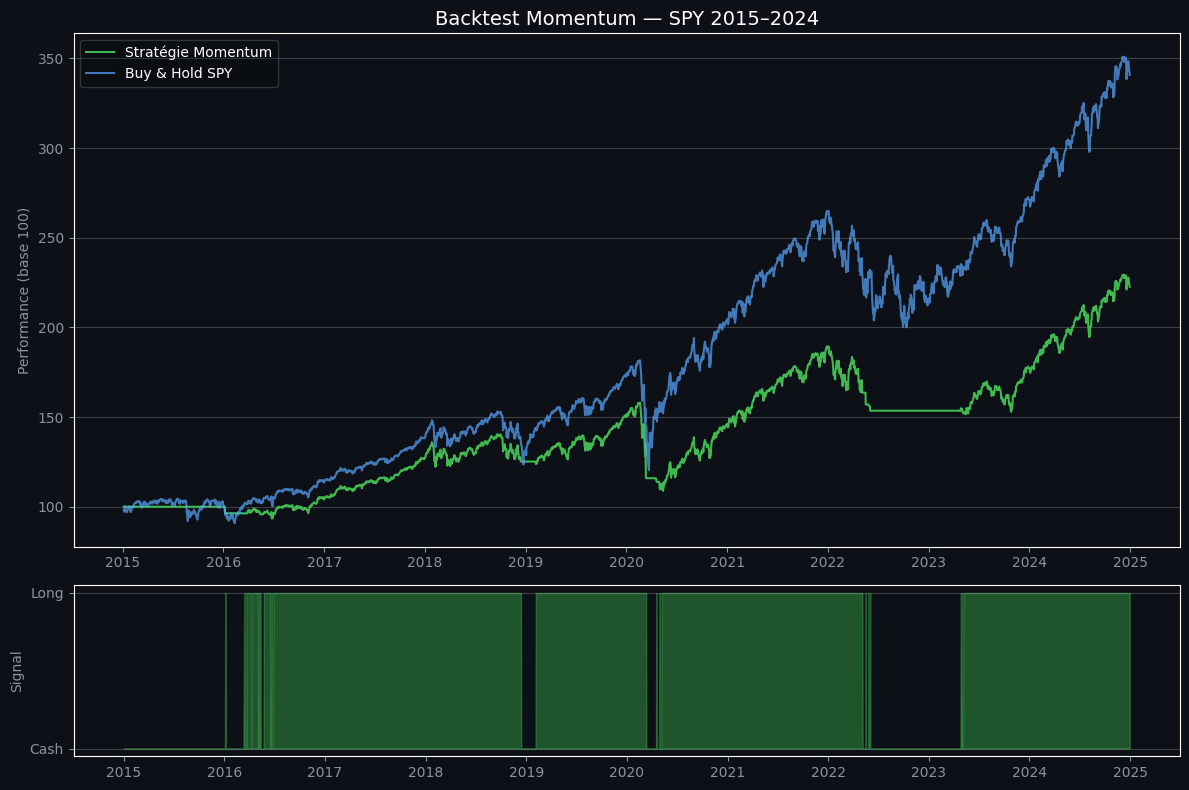

Graphique sauvegardé dans assets/performance.png


In [7]:
# Cellule 6 — Visualisation
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8),
                                gridspec_kw={'height_ratios': [3, 1]})
fig.patch.set_facecolor('#0d1117')

# Graphe 1 — Performance cumulée
ax1.plot(cumulative_strategy.index, cumulative_strategy,
         color='#3fb950', linewidth=1.5, label='Stratégie Momentum')
ax1.plot(cumulative_market.index, cumulative_market,
         color='#58a6ff', linewidth=1.5, alpha=0.7, label='Buy & Hold SPY')
ax1.set_facecolor('#0d1117')
ax1.set_ylabel('Performance (base 100)', color='#8b949e')
ax1.set_title('Backtest Momentum — SPY 2015–2024', color='white', fontsize=14)
ax1.legend(framealpha=0.2)
ax1.grid(axis='y', alpha=0.2)
ax1.tick_params(colors='#8b949e')

# Graphe 2 — Signal (investi ou cash)
ax2.fill_between(signal.index, signal,
                  color='#3fb950', alpha=0.4, label='En position')
ax2.set_facecolor('#0d1117')
ax2.set_ylabel('Signal', color='#8b949e')
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['Cash', 'Long'], color='#8b949e')
ax2.grid(axis='y', alpha=0.2)
ax2.tick_params(colors='#8b949e')

plt.tight_layout()
plt.savefig('assets/performance.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print("Graphique sauvegardé dans assets/performance.png")